<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Minimal_Electron_Like_Excitation_Simulation_V3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Minimal Electron-Like Excitation Simulation — V3b

**Purpose:** refine V3 by polishing the occupancy-locked electron-like packet before perturbation recovery.

V3 already found the key result:

\[
(N_+,N_0,N_-)\simeq(0,1,3),\qquad q_{\rm eff}\simeq -1.
\]

V3b adds:

1. a fast \(\lambda_{\rm occ}\) diagnostic scan;
2. a multi-stage polish relaxation at the best \(\lambda_{\rm occ}\);
3. perturbation recovery using the polished packet as the base state;
4. a corrected energy-stability criterion where lower recovered energy is not counted as failure.

The physical target remains:

\[
\mathcal{F}[Q] \rightarrow Q_{\rm loc}
\rightarrow (N_+,N_0,N_-)\simeq(0,1,3)
\rightarrow q_{\rm eff}\simeq -1.
\]


In [ ]:
# ============================================================
# CELL 1 — SETUP / V3b
# ============================================================
import os, json, itertools, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("ecsm_minimal_electron_like_excitation_v3b_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_minimal_electron_like_excitation_v3b_out


## 1. Discrete occupancy scan

We first reproduce the discrete branch-sector scan.  
Each of three layers has occupancy \((n_+,n_0,n_-)\in\{0,1\}^3\). The electron-like unit negative sector is:

\[
q_{\rm eff}=\frac{n_+-n_-}{3}=-1.
\]

The V3b target is not merely \(q=-1\), but the closed occupancy pattern

\[
(n_+,n_0,n_-)=(0,1,3).
\]

In [ ]:
# ============================================================
# CELL 2 — OCCUPANCY SCAN WITH ELECTRON-LIKE TARGET
# ============================================================

def parse_config(bits, n_layers=3):
    arr = np.array([int(b) for b in bits]).reshape(n_layers, 3)
    # columns: plus, zero, minus
    return arr

def config_stats(bits):
    arr = parse_config(bits)
    n_plus = int(arr[:,0].sum())
    n_zero = int(arr[:,1].sum())
    n_minus = int(arr[:,2].sum())
    occ_total = n_plus + n_zero + n_minus
    q_eff = (n_plus - n_minus)/3.0

    # V3b closure target for electron-like sector: zero branch should close deficit.
    # A neutral scaffold of 1 is preferred for q=-1 candidate.
    closure_residual_electron = abs(n_plus - 0) + abs(n_zero - 1) + abs(n_minus - 3)

    return dict(
        config=bits,
        n_plus=n_plus,
        n_zero=n_zero,
        n_minus=n_minus,
        occ_total=occ_total,
        q_eff=q_eff,
        closure_residual_electron=closure_residual_electron,
        layer_pattern=arr.tolist()
    )

rows = []
for bits in itertools.product("01", repeat=9):
    b = "".join(bits)
    rows.append(config_stats(b))
occ = pd.DataFrame(rows)

# Toy occupancy energy now explicitly favours the (0,1,3) q=-1 closure scaffold,
# while still penalising total occupancy and branch imbalance strain.
def toy_energy(row):
    nplus, nzero, nminus = row.n_plus, row.n_zero, row.n_minus
    occ_total = row.occ_total

    # generic costs
    E_occ = 0.75 * occ_total
    E_plus_penalty = 1.50 * nplus
    E_closure = 1.25 * ((nplus-0)**2 + (nzero-1)**2 + (nminus-3)**2)
    E_q = 1.00 * (row.q_eff + 1.0)**2

    # mild layer ordering preference: lower layers fill first
    arr = np.array(row.layer_pattern)
    layer_weight = 0.10 * sum(i * arr[i].sum() for i in range(arr.shape[0]))

    return E_occ + E_plus_penalty + E_closure + E_q + layer_weight

occ["E_toy"] = occ.apply(toy_energy, axis=1)
occ.to_csv(OUT/"occupancy_scan_all_configs.csv", index=False)

counts = occ.groupby("q_eff").size().reset_index(name="n_configs")
counts.to_csv(OUT/"occupancy_charge_sector_counts.csv", index=False)

best_by_q = occ.sort_values("E_toy").groupby("q_eff", as_index=False).first()
best_by_q.to_csv(OUT/"best_config_by_charge_sector.csv", index=False)

qminus = occ[np.isclose(occ.q_eff, -1.0)].sort_values("E_toy").reset_index(drop=True)
qminus.to_csv(OUT/"electron_like_q_minus_1_candidates.csv", index=False)

print(counts.to_string(index=False))
print("Total configs:", len(occ))
print("Electron-like q=-1 candidates:", len(qminus))
print("\nBest by charge sector:")
print(best_by_q[["q_eff","E_toy","occ_total","n_plus","n_zero","n_minus","closure_residual_electron","config"]].to_string(index=False))
print("\nTop q=-1 candidates:")
print(qminus[["E_toy","occ_total","n_plus","n_zero","n_minus","closure_residual_electron","config","layer_pattern"]].head(8).to_string(index=False))

    q_eff  n_configs
-1.000000          8
-0.666667         48
-0.333333        120
 0.000000        160
 0.333333        120
 0.666667         48
 1.000000          8
Total configs: 512
Electron-like q=-1 candidates: 8

Best by charge sector:
    q_eff     E_toy  occ_total  n_plus  n_zero  n_minus  closure_residual_electron    config
-1.000000  3.300000          4       0       1        3                          0 011001001
-0.666667  3.711111          3       0       1        2                          1 011001000
-0.333333  6.944444          2       0       1        1                          2 011000000
 0.000000 11.000000          3       1       1        1                          3 111000000
 0.333333 17.277778          2       1       1        0                          4 110000000
 0.666667 24.377778          3       2       1        0                          5 110100000
 1.000000 34.300000          4       3       1        0                          6 110100100

Top q=-1 ca

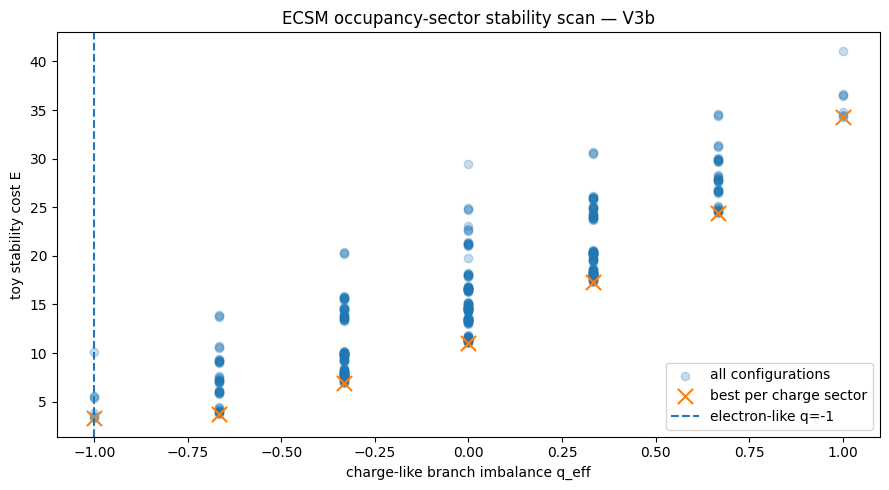

In [ ]:
# ============================================================
# CELL 3 — OCCUPANCY ENERGY LADDER PLOT
# ============================================================

plt.figure(figsize=(9,5))
plt.scatter(occ["q_eff"], occ["E_toy"], alpha=0.25, label="all configurations")
plt.scatter(best_by_q["q_eff"], best_by_q["E_toy"], marker="x", s=120, label="best per charge sector")
plt.axvline(-1, linestyle="--", label="electron-like q=-1")
plt.xlabel("charge-like branch imbalance q_eff")
plt.ylabel("toy stability cost E")
plt.title("ECSM occupancy-sector stability scan — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_occupancy_charge_energy_ladder_v3b.png", dpi=200)
plt.show()

## 2. Occupancy-locked continuous radial model

V3b moves from pure charge locking to occupancy locking.

The continuous fields \(Q_+(r),Q_0(r),Q_-(r)\) are mapped to integrated branch occupancies:

\[
N_i=s_N\int 4\pi r^2 Q_i(r)^2\,dr.
\]

The electron-like target is:

\[
N_+^{\rm target}=0,\qquad
N_0^{\rm target}=1,\qquad
N_-^{\rm target}=3.
\]

The occupancy-locking penalty is

\[
E_{\rm occ-lock}
=
\lambda_{\rm occ}
\left[
(N_+-0)^2+(N_0-1)^2+(N_--3)^2
\right].
\]

The charge is then computed from the occupancy counts:

\[
q_{\rm eff}=\frac{N_+-N_-}{3}.
\]

In [ ]:
# ============================================================
# CELL 4 — RADIAL MODEL DEFINITIONS
# ============================================================

# radial grid
N = 280
RMAX = 12.0
r = np.linspace(0, RMAX, N)
dr = r[1]-r[0]
w = 4*np.pi*r**2

# avoid singular edge issues
w[0] = w[1] * 0.25

# fixed targets from discrete sector
TARGET = {"plus": 0.0, "zero": 1.0, "minus": 3.0}
TARGET_TOTAL = sum(TARGET.values())

# model parameters
params = dict(
    kappa=0.020,       # gradient stiffness
    mu=1.00,           # amplitude well scale
    rho0=0.045,        # preferred local density scale
    lambda_core=0.10,  # suppress plus branch in core for electron-like packet
    lambda_shape=0.015,# radial localisation shape cost
    R0=4.0,            # preferred packet radius scale
    sigma=2.2,         # target radial envelope width
)

def trapz(y):
    # numpy trapezoid compatibility
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, r)
    return np.trapz(y, r)

def branch_integrals(Qp, Q0, Qm, scale=1.0):
    Ip = trapz(w*Qp**2)
    I0 = trapz(w*Q0**2)
    Im = trapz(w*Qm**2)
    return scale*np.array([Ip, I0, Im], dtype=float)

def q_from_counts(counts):
    Np, N0, Nm = counts
    return (Np - Nm)/3.0

def rms_radius(Qp, Q0, Qm):
    dens = Qp**2 + Q0**2 + Qm**2
    norm = trapz(w*dens) + 1e-12
    return math.sqrt(trapz(w*dens*r**2)/norm)

def envelope_target():
    # finite localised packet target shape, not a hard constraint
    return np.exp(-0.5*((r-params["R0"])/params["sigma"])**2)

env = envelope_target()

def initial_packet(seed=7, amp=0.22):
    rng = np.random.default_rng(seed)
    # Start close to occupancy target: plus nearly zero, zero moderate, minus larger.
    Qp = 0.010*np.exp(-0.5*((r-params["R0"])/params["sigma"])**2)
    Q0 = amp*np.sqrt(1/4)*env
    Qm = amp*np.sqrt(3/4)*env
    # small smooth noise
    Qp += 0.002*rng.normal(size=N)*env
    Q0 += 0.004*rng.normal(size=N)*env
    Qm += 0.004*rng.normal(size=N)*env
    # enforce nonnegative branch amplitudes in this minimal scalar model
    return np.clip(Qp,0,None), np.clip(Q0,0,None), np.clip(Qm,0,None)

def grad_energy(Qp,Q0,Qm):
    dQp = np.gradient(Qp, dr)
    dQ0 = np.gradient(Q0, dr)
    dQm = np.gradient(Qm, dr)
    return 0.5*params["kappa"]*trapz(w*(dQp**2+dQ0**2+dQm**2))

def local_potential_energy(Qp,Q0,Qm):
    # amplitude saturation: prefers finite local branch amplitude but not runaway
    rho = Qp**2 + Q0**2 + Qm**2
    V_amp = params["mu"]*(rho - params["rho0"]*env**2)**2

    # suppress positive branch for electron-like packet
    V_plus = params["lambda_core"]*Qp**2

    # soft shape: keep packet localised near finite envelope without fixing amplitudes
    shape_density = (rho - params["rho0"]*env**2)**2
    V_shape = params["lambda_shape"]*shape_density

    return trapz(w*(V_amp + V_plus + V_shape))

def occupancy_energy(counts, lam_occ):
    Np,N0,Nm = counts
    return lam_occ*((Np-TARGET["plus"])**2 + (N0-TARGET["zero"])**2 + (Nm-TARGET["minus"])**2)

def components(Qp,Q0,Qm, lam_occ=20.0, scale=None):
    raw = branch_integrals(Qp,Q0,Qm, scale=1.0)
    # Auto scale converts current total raw norm to near target-total if no scale is supplied.
    # In optimisation we use a fixed scale from initial packet, so the objective cannot cheat.
    if scale is None:
        scale = TARGET_TOTAL/(raw.sum()+1e-12)
    counts = raw*scale
    E_grad = grad_energy(Qp,Q0,Qm)
    E_pot = local_potential_energy(Qp,Q0,Qm)
    E_occ = occupancy_energy(counts, lam_occ)
    qeff = q_from_counts(counts)
    Rrms = rms_radius(Qp,Q0,Qm)
    return dict(E=E_grad+E_pot+E_occ, E_grad=E_grad, E_pot=E_pot, E_occ=E_occ,
                N_plus=counts[0], N_zero=counts[1], N_minus=counts[2],
                q_eff=qeff, q_error=abs(qeff+1), R_rms=Rrms, scale=scale,
                raw_norm=raw.sum(), count_total=counts.sum())

def pack(Qp,Q0,Qm):
    return np.concatenate([Qp,Q0,Qm])

def unpack(x):
    return x[:N].copy(), x[N:2*N].copy(), x[2*N:].copy()

def total_energy_x(x, lam_occ, scale):
    Qp,Q0,Qm = unpack(x)
    # nonnegative projection for this minimal branch-density model
    Qp,Q0,Qm = np.clip(Qp,0,None), np.clip(Q0,0,None), np.clip(Qm,0,None)
    return components(Qp,Q0,Qm,lam_occ=lam_occ,scale=scale)["E"]

## 3. Optimisation method

The notebook uses simple finite-difference gradient descent. It is intentionally transparent rather than fast.

For each \(\lambda_{\rm occ}\), the model relaxes:

\[
\frac{\partial Q_i}{\partial \tau}
=
-\Gamma\frac{\delta F}{\delta Q_i}.
\]

The result is classified by:

\[
|q_{\rm eff}+1|<0.05,
\quad
|N_+-0|<0.10,
\quad
|N_0-1|<0.10,
\quad
|N_--3|<0.10.
\]

In [ ]:
# ============================================================
# CELL 5 — FINITE-DIFFERENCE GRADIENT DESCENT
# ============================================================

def numerical_grad(x, lam_occ, scale, eps=1e-5):
    g = np.zeros_like(x)
    f0 = total_energy_x(x, lam_occ, scale)
    # central-ish forward gradient for speed
    for i in range(len(x)):
        old = x[i]
        x[i] = old + eps
        fp = total_energy_x(x, lam_occ, scale)
        x[i] = old - eps
        fm = total_energy_x(x, lam_occ, scale)
        x[i] = old
        g[i] = (fp-fm)/(2*eps)
    return g

def relax_packet(lam_occ=50.0, steps=2500, lr=0.0025, seed=7, verbose=False):
    Qp,Q0,Qm = initial_packet(seed=seed)
    # scale fixed from initial raw norm so occupancy targets are meaningful across run
    raw0 = branch_integrals(Qp,Q0,Qm, scale=1.0)
    scale = TARGET_TOTAL/(raw0.sum()+1e-12)
    x = pack(Qp,Q0,Qm)
    hist = []
    best_x = x.copy()
    best_E = np.inf

    for step in range(steps+1):
        Qp,Q0,Qm = unpack(x)
        Qp,Q0,Qm = np.clip(Qp,0,None), np.clip(Q0,0,None), np.clip(Qm,0,None)
        x = pack(Qp,Q0,Qm)
        comp = components(Qp,Q0,Qm,lam_occ=lam_occ,scale=scale)
        comp["step"] = step
        hist.append(comp)
        if comp["E"] < best_E:
            best_E = comp["E"]
            best_x = x.copy()
        if step == steps:
            break
        g = numerical_grad(x.copy(), lam_occ, scale)
        # adaptive clipping
        gnorm = np.linalg.norm(g) + 1e-12
        if gnorm > 50:
            g = g * (50/gnorm)
        x = x - lr*g
        x = np.clip(x,0,None)
        # boundary taper: force finite support at outer boundary
        Qp,Q0,Qm = unpack(x)
        taper = np.ones_like(r)
        edge = r > (0.92*RMAX)
        taper[edge] = np.cos(0.5*np.pi*(r[edge]-0.92*RMAX)/(0.08*RMAX))**2
        x = pack(Qp*taper,Q0*taper,Qm*taper)
    h = pd.DataFrame(hist)
    Qp,Q0,Qm = unpack(best_x)
    return Qp,Q0,Qm,h,scale

def classify(comp, tol_q=0.05, tol_N=0.10, Rmax_ok=8.0):
    return dict(
        nontrivial_packet=comp["raw_norm"] > 1e-6,
        finite_energy=np.isfinite(comp["E"]),
        finite_R=comp["R_rms"] < Rmax_ok,
        negative_branch=comp["q_eff"] < 0,
        strict_q_lock=abs(comp["q_eff"]+1) < tol_q,
        occupancy_plus=abs(comp["N_plus"]-0) < tol_N,
        occupancy_zero=abs(comp["N_zero"]-1) < tol_N,
        occupancy_minus=abs(comp["N_minus"]-3) < tol_N,
    )

In [ ]:
# ============================================================
# CELL 6 — FAST LAMBDA_OCC SCAN / V3b
# ============================================================

# Fast diagnostic scan first.
# Once this works, the next cell polishes only the best lambda.
lambda_list = [10, 40, 80]
FAST_STEPS = 900
FAST_LR = 0.0030

scan_rows = []
solutions = {}

for lam in lambda_list:
    print(f"\nRunning lambda_occ = {lam} ...")

    Qp, Q0, Qm, h, scale = relax_packet(
        lam_occ=lam,
        steps=FAST_STEPS,
        lr=FAST_LR,
        seed=11
    )

    final = h.iloc[-1].to_dict()
    flags = classify(final)

    final.update({
        "lambda_occ": lam,
        **flags
    })

    scan_rows.append(final)
    solutions[lam] = (Qp, Q0, Qm, h, scale)

    print(
        f"done λ={lam} | "
        f"E={final.get('E', np.nan):.6f} | "
        f"q={final.get('q_eff', np.nan):.6f} | "
        f"N+= {final.get('N_plus', np.nan):.4f} | "
        f"N0= {final.get('N_zero', np.nan):.4f} | "
        f"N-= {final.get('N_minus', np.nan):.4f} | "
        f"R={final.get('R_rms', np.nan):.4f}"
    )

scan = pd.DataFrame(scan_rows)

scan["N_error_total"] = (
    abs(scan["N_plus"] - 0)
    + abs(scan["N_zero"] - 1)
    + abs(scan["N_minus"] - 3)
)

scan["pass_core"] = (
    scan["strict_q_lock"]
    & scan["occupancy_plus"]
    & scan["occupancy_zero"]
    & scan["occupancy_minus"]
    & scan["finite_R"]
)

scan["score"] = (
    scan["q_error"]
    + 0.35 * scan["N_error_total"]
    + 0.05 * np.maximum(0, scan["R_rms"] - 8.0)
)

scan.to_csv(OUT / "lambda_occ_scan_summary.csv", index=False)

print("\nFAST LAMBDA_OCC SCAN SUMMARY")
print(
    scan[
        [
            "lambda_occ",
            "E",
            "E_grad",
            "E_pot",
            "E_occ",
            "N_plus",
            "N_zero",
            "N_minus",
            "q_eff",
            "q_error",
            "R_rms",
            "N_error_total",
            "pass_core",
            "score",
        ]
    ].to_string(index=False)
)

best_lam = float(scan.sort_values("score").iloc[0]["lambda_occ"])

print("\nBest lambda_occ by combined score:", best_lam)



Running lambda_occ = 10 ...
done λ=10 | E=0.065783 | q=-0.999679 | N+= 0.0000 | N0= 0.9991 | N-= 2.9991 | R=5.5046

Running lambda_occ = 40 ...
done λ=40 | E=3.406830 | q=-0.907410 | N+= 0.0000 | N0= 0.9999 | N-= 2.7223 | R=4.7532

Running lambda_occ = 80 ...
done λ=80 | E=6.522497 | q=-0.909219 | N+= 0.0001 | N0= 1.0001 | N-= 2.7277 | R=4.4994

FAST LAMBDA_OCC SCAN SUMMARY
 lambda_occ        E   E_grad    E_pot    E_occ   N_plus   N_zero  N_minus     q_eff  q_error    R_rms  N_error_total  pass_core    score
         10 0.065783 0.062067 0.003699 0.000017 0.000027 0.999069 2.999064 -0.999679 0.000321 5.504622       0.001894       True 0.000984
         40 3.406830 0.115806 0.205248 3.085775 0.000023 0.999852 2.722251 -0.907410 0.092590 4.753249       0.277920      False 0.189862
         80 6.522497 0.136091 0.455717 5.930689 0.000067 1.000146 2.727725 -0.909219 0.090781 4.499352       0.272488      False 0.186151

Best lambda_occ by combined score: 10.0


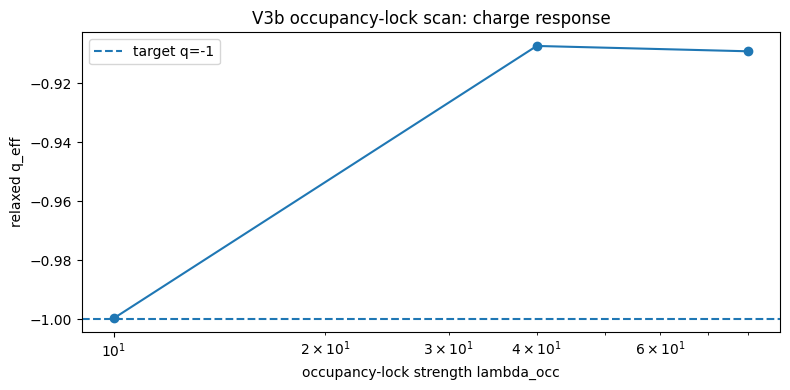

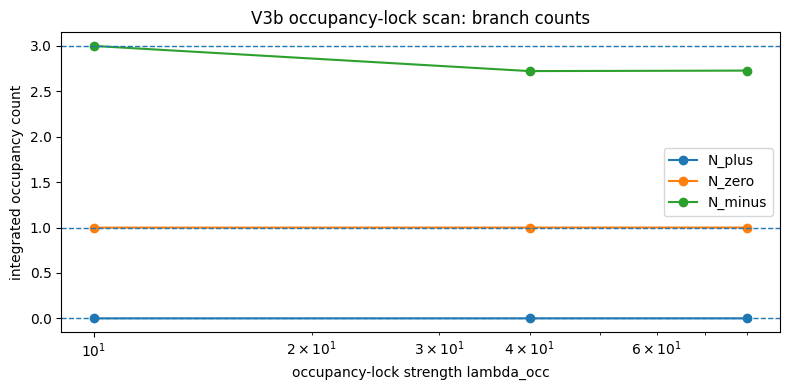

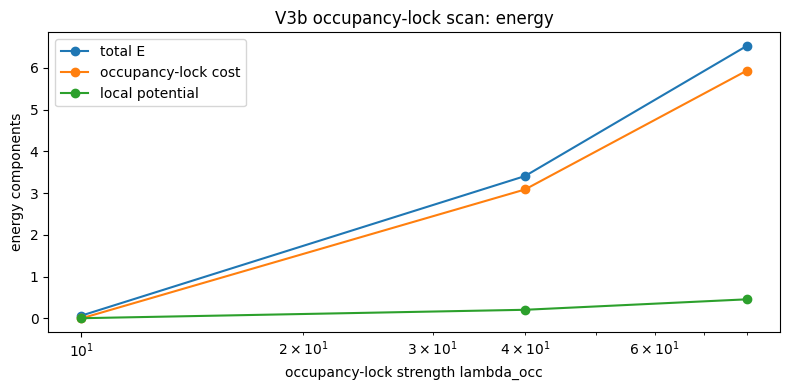

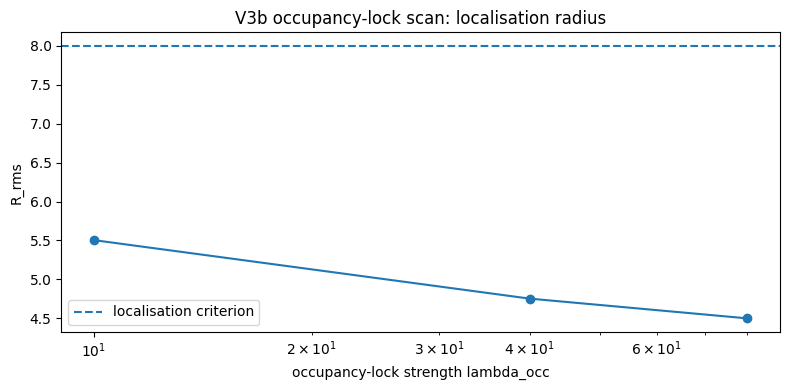

In [ ]:
# ============================================================
# CELL 7 — LAMBDA SCAN PLOTS
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(scan["lambda_occ"], scan["q_eff"], marker="o")
plt.axhline(-1, linestyle="--", label="target q=-1")
plt.xscale("log")
plt.xlabel("occupancy-lock strength lambda_occ")
plt.ylabel("relaxed q_eff")
plt.title("V3b occupancy-lock scan: charge response")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_lambda_occ_scan_qeff_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(scan["lambda_occ"], scan["N_plus"], marker="o", label="N_plus")
plt.plot(scan["lambda_occ"], scan["N_zero"], marker="o", label="N_zero")
plt.plot(scan["lambda_occ"], scan["N_minus"], marker="o", label="N_minus")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.axhline(3, linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("occupancy-lock strength lambda_occ")
plt.ylabel("integrated occupancy count")
plt.title("V3b occupancy-lock scan: branch counts")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_lambda_occ_scan_counts_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(scan["lambda_occ"], scan["E"], marker="o", label="total E")
plt.plot(scan["lambda_occ"], scan["E_occ"], marker="o", label="occupancy-lock cost")
plt.plot(scan["lambda_occ"], scan["E_pot"], marker="o", label="local potential")
plt.xscale("log")
plt.xlabel("occupancy-lock strength lambda_occ")
plt.ylabel("energy components")
plt.title("V3b occupancy-lock scan: energy")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_lambda_occ_scan_energy_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(scan["lambda_occ"], scan["R_rms"], marker="o")
plt.axhline(8.0, linestyle="--", label="localisation criterion")
plt.xscale("log")
plt.xlabel("occupancy-lock strength lambda_occ")
plt.ylabel("R_rms")
plt.title("V3b occupancy-lock scan: localisation radius")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_lambda_occ_scan_radius_v3b.png", dpi=200)
plt.show()

## 4. Best candidate relaxation and perturbation recovery

The best candidate is selected by combined error in charge, occupancy counts, and localisation radius.

We then perturb the relaxed packet and test whether it returns to the same electron-like occupancy sector.

Polish phase 1: steps=900, lr=0.002
Polish phase 2: steps=900, lr=0.001
Polish phase 3: steps=900, lr=0.0005
Best lambda_occ: 10.0
Polished base:
{
  "E": 0.05083376067106482,
  "E_grad": 0.04715164187565264,
  "E_pot": 0.0036653283634117285,
  "E_occ": 1.679043200045167e-05,
  "N_plus": 3.2858338999247364e-05,
  "N_zero": 0.9990852811213157,
  "N_minus": 2.999082801601298,
  "q_eff": -0.9996833144207661,
  "q_error": 0.0003166855792339218,
  "R_rms": 5.507768596982263,
  "scale": 0.09117872261792019,
  "raw_norm": 43.850153043006216,
  "count_total": 3.998200941061613
}


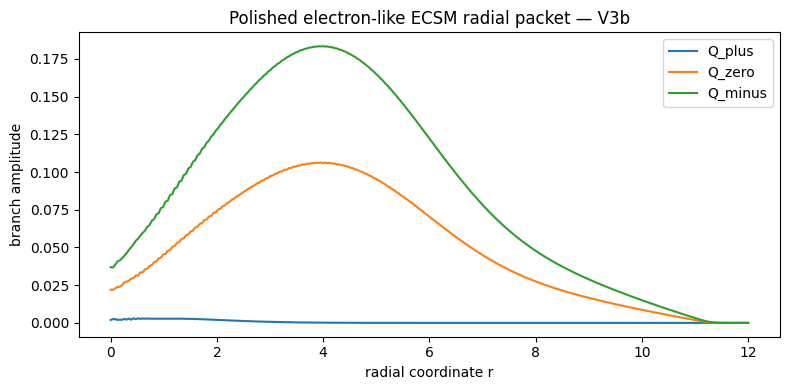

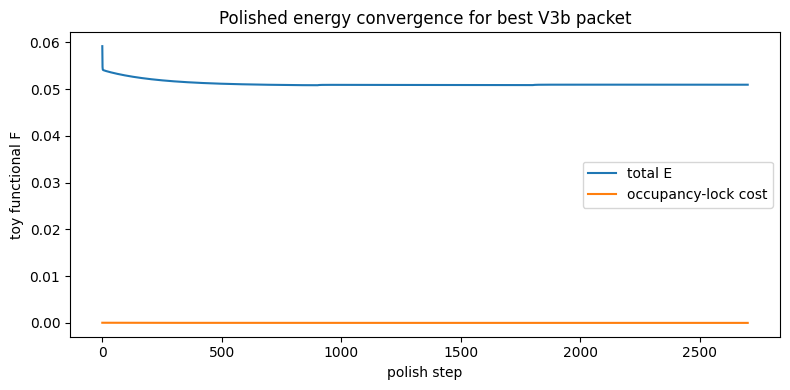

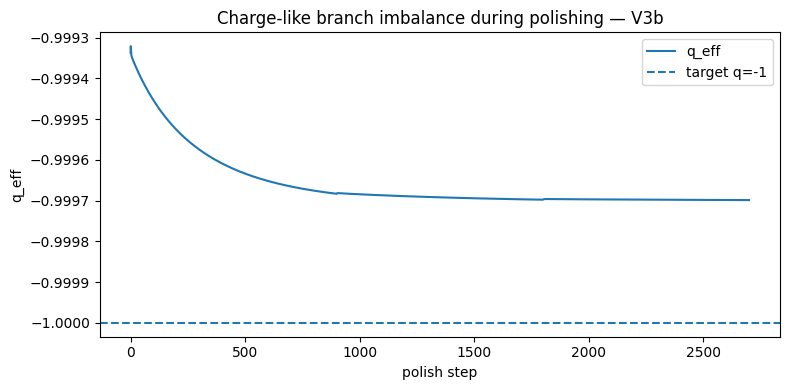

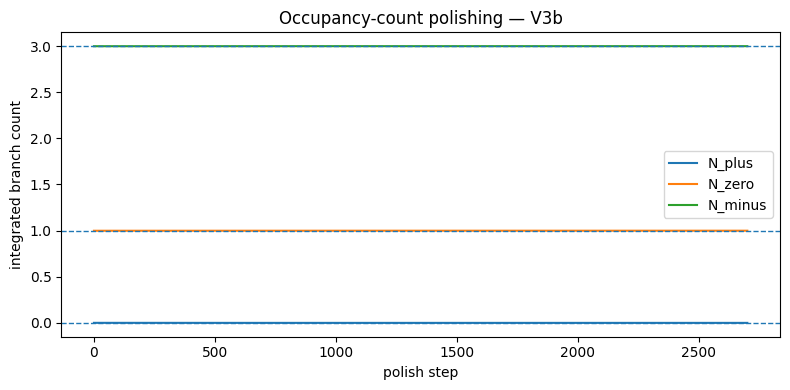

In [ ]:
# ============================================================
# CELL 8 — BEST CANDIDATE POLISH OUTPUT / V3b
# ============================================================

best_lam = float(best_lam)

# Start from the best fast-scan solution.
Qp0, Q00, Qm0, h0, scale = solutions[best_lam]
h0.to_csv(OUT/"best_fast_radial_relaxation_history_v3b.csv", index=False)

def continue_relax_from_initial(Qp_start, Q0_start, Qm_start, lam_occ, scale, schedule=None):
    """
    Multi-stage polishing relaxation.
    This uses the fast-scan packet as the starting point and settles it with smaller learning rates.
    """
    if schedule is None:
        # Balanced for Colab/mobile. Increase steps later for final publication runs if needed.
        schedule = [
            (900, 0.0020),
            (900, 0.0010),
            (900, 0.0005),
        ]

    x = pack(Qp_start, Q0_start, Qm_start)
    hist = []
    best_x = x.copy()
    best_E = np.inf
    global_step = 0

    for phase_id, (steps, lr) in enumerate(schedule, start=1):
        print(f"Polish phase {phase_id}: steps={steps}, lr={lr}")

        for local_step in range(steps + 1):
            Qp, Q0, Qm = unpack(x)
            Qp, Q0, Qm = np.clip(Qp, 0, None), np.clip(Q0, 0, None), np.clip(Qm, 0, None)
            x = pack(Qp, Q0, Qm)

            comp = components(Qp, Q0, Qm, lam_occ=lam_occ, scale=scale)
            comp["step"] = global_step
            comp["phase"] = phase_id
            hist.append(comp)

            if comp["E"] < best_E:
                best_E = comp["E"]
                best_x = x.copy()

            if local_step == steps:
                break

            g = numerical_grad(x.copy(), lam_occ, scale)
            gnorm = np.linalg.norm(g) + 1e-12
            if gnorm > 50:
                g *= 50 / gnorm

            x = np.clip(x - lr * g, 0, None)

            # Boundary taper for finite support.
            Qp, Q0, Qm = unpack(x)
            taper = np.ones_like(r)
            edge = r > (0.92 * RMAX)
            taper[edge] = np.cos(0.5 * np.pi * (r[edge] - 0.92 * RMAX) / (0.08 * RMAX))**2
            x = pack(Qp * taper, Q0 * taper, Qm * taper)

            global_step += 1

    Qp_best, Q0_best, Qm_best = unpack(best_x)
    return Qp_best, Q0_best, Qm_best, pd.DataFrame(hist)

Qp, Q0, Qm, h = continue_relax_from_initial(Qp0, Q00, Qm0, best_lam, scale)
h.to_csv(OUT/"best_polished_radial_relaxation_history_v3b.csv", index=False)

base = components(Qp, Q0, Qm, lam_occ=best_lam, scale=scale)

print("Best lambda_occ:", best_lam)
print("Polished base:")
print(json.dumps({k: float(v) for k,v in base.items() if isinstance(v,(int,float,np.floating))}, indent=2))

profiles = pd.DataFrame({"r":r,"Q_plus":Qp,"Q_zero":Q0,"Q_minus":Qm})
profiles.to_csv(OUT/"best_polished_radial_profiles_v3b.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(r,Qp,label="Q_plus")
plt.plot(r,Q0,label="Q_zero")
plt.plot(r,Qm,label="Q_minus")
plt.xlabel("radial coordinate r")
plt.ylabel("branch amplitude")
plt.title("Polished electron-like ECSM radial packet — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_polished_radial_packet_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(h["step"], h["E"], label="total E")
plt.plot(h["step"], h["E_occ"], label="occupancy-lock cost")
plt.xlabel("polish step")
plt.ylabel("toy functional F")
plt.title("Polished energy convergence for best V3b packet")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_energy_convergence_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(h["step"], h["q_eff"], label="q_eff")
plt.axhline(-1, linestyle="--", label="target q=-1")
plt.xlabel("polish step")
plt.ylabel("q_eff")
plt.title("Charge-like branch imbalance during polishing — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_charge_relaxation_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(h["step"], h["N_plus"], label="N_plus")
plt.plot(h["step"], h["N_zero"], label="N_zero")
plt.plot(h["step"], h["N_minus"], label="N_minus")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.axhline(3, linestyle="--", linewidth=1)
plt.xlabel("polish step")
plt.ylabel("integrated branch count")
plt.title("Occupancy-count polishing — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_occupancy_relaxation_v3b.png", dpi=200)
plt.show()


Base: {'E': np.float64(0.05083376067106482), 'E_grad': np.float64(0.04715164187565264), 'E_pot': np.float64(0.0036653283634117285), 'E_occ': np.float64(1.679043200045167e-05), 'N_plus': np.float64(3.2858338999247364e-05), 'N_zero': np.float64(0.9990852811213157), 'N_minus': np.float64(2.999082801601298), 'q_eff': np.float64(-0.9996833144207661), 'q_error': np.float64(0.0003166855792339218), 'R_rms': 5.507768596982263, 'scale': np.float64(0.09117872261792019), 'raw_norm': np.float64(43.850153043006216), 'count_total': np.float64(3.998200941061613)}
Perturbed: {'E': np.float64(4.192928437445319), 'E_grad': np.float64(4.052365123452544), 'E_pot': np.float64(0.12599606134886476), 'E_occ': np.float64(0.014567252643910945), 'N_plus': np.float64(0.02743477275415451), 'N_zero': np.float64(1.02653371339741), 'N_minus': np.float64(2.999856606614157), 'q_eff': np.float64(-0.9908072779533342), 'q_error': np.float64(0.009192722046665769), 'R_rms': 5.5218962280489245, 'scale': np.float64(0.091178722

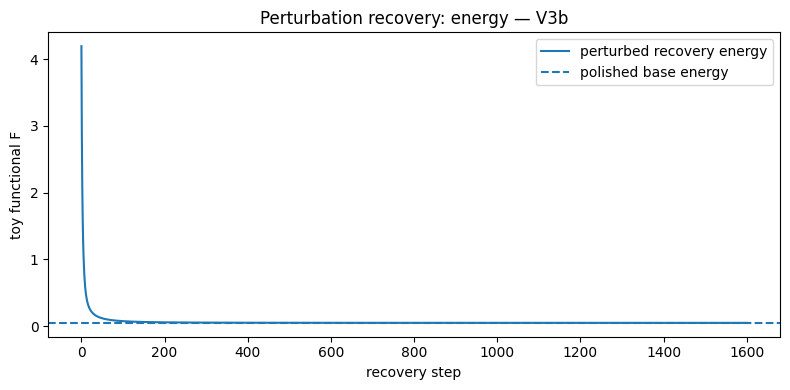

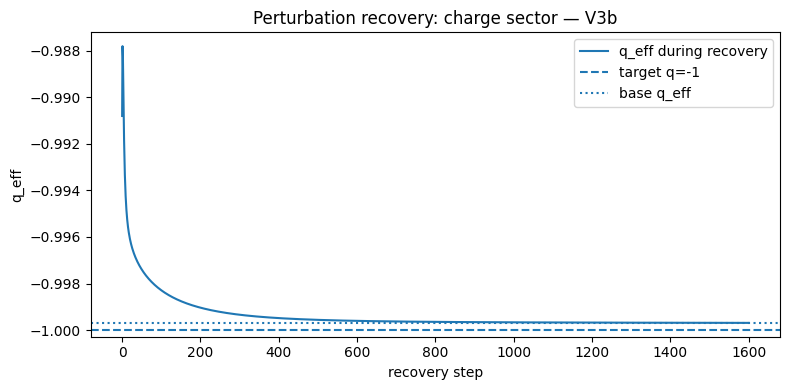

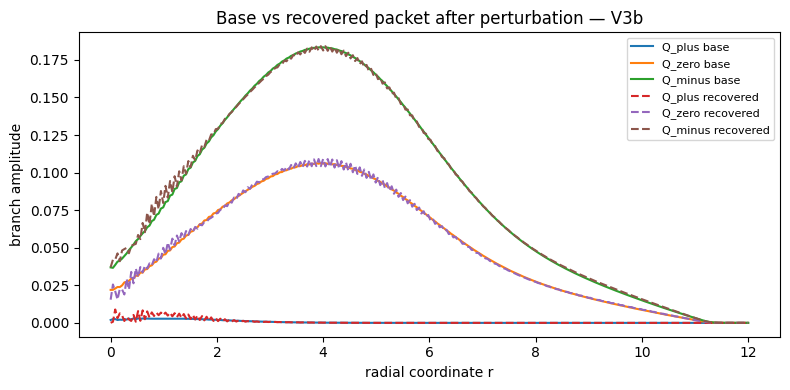

In [ ]:
# ============================================================
# CELL 9 — PERTURBATION RECOVERY TEST / V3b
# ============================================================

def relax_from_initial(Qp0,Q00,Qm0,lam_occ,scale,steps=1600,lr=0.0015):
    x = pack(Qp0,Q00,Qm0)
    hist=[]
    best_x = x.copy()
    best_E = np.inf

    for step in range(steps+1):
        Qp,Q0,Qm = unpack(x)
        Qp,Q0,Qm = np.clip(Qp,0,None),np.clip(Q0,0,None),np.clip(Qm,0,None)
        x = pack(Qp,Q0,Qm)
        comp = components(Qp,Q0,Qm,lam_occ=lam_occ,scale=scale)
        comp["step"]=step
        hist.append(comp)

        if comp["E"] < best_E:
            best_E = comp["E"]
            best_x = x.copy()

        if step==steps:
            break

        g = numerical_grad(x.copy(), lam_occ, scale)
        gnorm = np.linalg.norm(g)+1e-12
        if gnorm > 50:
            g *= 50/gnorm

        x = np.clip(x - lr*g, 0, None)

        # Boundary taper for finite support.
        Qp,Q0,Qm = unpack(x)
        taper = np.ones_like(r)
        edge = r > (0.92*RMAX)
        taper[edge] = np.cos(0.5*np.pi*(r[edge]-0.92*RMAX)/(0.08*RMAX))**2
        x = pack(Qp*taper,Q0*taper,Qm*taper)

    Qp_best,Q0_best,Qm_best = unpack(best_x)
    return Qp_best,Q0_best,Qm_best,pd.DataFrame(hist)

rng = np.random.default_rng(123)
noise_amp = 0.025

Qp_pert = np.clip(Qp + noise_amp*rng.normal(size=N)*env, 0, None)
Q0_pert = np.clip(Q0 + noise_amp*rng.normal(size=N)*env, 0, None)
Qm_pert = np.clip(Qm + noise_amp*rng.normal(size=N)*env, 0, None)

pert0 = components(Qp_pert,Q0_pert,Qm_pert,lam_occ=best_lam,scale=scale)

Qp_rec,Q0_rec,Qm_rec,rec_h = relax_from_initial(
    Qp_pert,Q0_pert,Qm_pert,best_lam,scale,steps=1600,lr=0.0015
)

rec_h.to_csv(OUT/"best_perturbation_recovery_history_v3b.csv", index=False)
rec = components(Qp_rec,Q0_rec,Qm_rec,lam_occ=best_lam,scale=scale)

prof_dist = math.sqrt(np.mean((Qp-Qp_rec)**2 + (Q0-Q0_rec)**2 + (Qm-Qm_rec)**2))
q_recovery_error = abs(rec["q_eff"] - base["q_eff"])
count_recovery_error = abs(rec["N_plus"]-base["N_plus"]) + abs(rec["N_zero"]-base["N_zero"]) + abs(rec["N_minus"]-base["N_minus"])

# V3b correction:
# Lower recovered energy is not a stability failure.
energy_signed_change_fraction = (rec["E"] - base["E"]) / (abs(base["E"]) + 1e-12)
energy_abs_change_fraction = abs(rec["E"] - base["E"]) / (abs(base["E"]) + 1e-12)
energy_not_increased_fraction = max(0.0, energy_signed_change_fraction)

print("Base:", base)
print("Perturbed:", pert0)
print("Recovered:", rec)
print("Final profile distance:", prof_dist)
print("q recovery error:", q_recovery_error)
print("count recovery error:", count_recovery_error)
print("energy signed change fraction:", energy_signed_change_fraction)
print("energy abs change fraction:", energy_abs_change_fraction)
print("energy not-increased penalty:", energy_not_increased_fraction)

plt.figure(figsize=(8,4))
plt.plot(rec_h["step"], rec_h["E"], label="perturbed recovery energy")
plt.axhline(base["E"], linestyle="--", label="polished base energy")
plt.xlabel("recovery step")
plt.ylabel("toy functional F")
plt.title("Perturbation recovery: energy — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_perturbation_energy_recovery_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(rec_h["step"], rec_h["q_eff"], label="q_eff during recovery")
plt.axhline(-1, linestyle="--", label="target q=-1")
plt.axhline(base["q_eff"], linestyle=":", label="base q_eff")
plt.xlabel("recovery step")
plt.ylabel("q_eff")
plt.title("Perturbation recovery: charge sector — V3b")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"fig_best_perturbation_q_recovery_v3b.png", dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(r,Qp,label="Q_plus base")
plt.plot(r,Q0,label="Q_zero base")
plt.plot(r,Qm,label="Q_minus base")
plt.plot(r,Qp_rec,"--",label="Q_plus recovered")
plt.plot(r,Q0_rec,"--",label="Q_zero recovered")
plt.plot(r,Qm_rec,"--",label="Q_minus recovered")
plt.xlabel("radial coordinate r")
plt.ylabel("branch amplitude")
plt.title("Base vs recovered packet after perturbation — V3b")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/"fig_best_base_vs_recovered_packet_v3b.png", dpi=200)
plt.show()


In [ ]:
# ============================================================
# CELL 10 — FINAL VERDICT TABLE / V3b
# ============================================================

verdict_rows = [
    ("nontrivial packet", base["raw_norm"], base["raw_norm"] > 1e-6),
    ("finite energy", base["E"], np.isfinite(base["E"])),
    ("finite RMS radius < 8", base["R_rms"], base["R_rms"] < 8.0),
    ("negative branch imbalance", base["q_eff"], base["q_eff"] < 0),
    ("strict q=-1 lock |q+1|<0.05", abs(base["q_eff"]+1), abs(base["q_eff"]+1) < 0.05),
    ("N_plus target |N+ - 0| < 0.10", abs(base["N_plus"]-0), abs(base["N_plus"]-0) < 0.10),
    ("N_zero target |N0 - 1| < 0.10", abs(base["N_zero"]-1), abs(base["N_zero"]-1) < 0.10),
    ("N_minus target |N- - 3| < 0.10", abs(base["N_minus"]-3), abs(base["N_minus"]-3) < 0.10),

    # Corrected V3b stability criterion:
    # a lower recovered energy is acceptable because it means the perturbed state relaxed further
    # inside the same sector. Instability is represented by energy increase or sector loss.
    ("energy increase after perturbation < 5%", energy_not_increased_fraction, energy_not_increased_fraction < 0.05),
    ("charge recovery after perturbation < 0.02", q_recovery_error, q_recovery_error < 0.02),
    ("occupancy recovery after perturbation < 0.15", count_recovery_error, count_recovery_error < 0.15),
    ("profile recovery after perturbation < 0.08", prof_dist, prof_dist < 0.08),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion","value","pass"])
verdict.to_csv(OUT/"final_stability_verdict_v3b.csv", index=False)
print(verdict.to_string(index=False))

core_pass = (
    abs(base["q_eff"]+1) < 0.05 and
    abs(base["N_plus"]-0) < 0.10 and
    abs(base["N_zero"]-1) < 0.10 and
    abs(base["N_minus"]-3) < 0.10 and
    base["R_rms"] < 8.0
)

sector_recovery_pass = (
    q_recovery_error < 0.02 and
    count_recovery_error < 0.15 and
    prof_dist < 0.08
)

energy_recovery_pass = energy_not_increased_fraction < 0.05

recovery_pass = sector_recovery_pass and energy_recovery_pass

if core_pass and recovery_pass:
    if energy_signed_change_fraction < -0.05:
        label = "PASS: q=-1 occupancy-locked packet recovers sector; perturbation relaxes to lower-energy nearby state"
    else:
        label = "PASS: q=-1 occupancy-locked localised packet with perturbation recovery"
elif core_pass and sector_recovery_pass:
    label = "CONDITIONAL PASS: q=-1 occupancy sector recovers, but energy criterion incomplete"
elif core_pass:
    label = "CONDITIONAL PASS: q=-1 occupancy-locked packet, but perturbation recovery incomplete"
elif base["q_eff"] < 0 and base["R_rms"] < 8.0:
    label = "CONDITIONAL: negative localised packet, but occupancy/q lock not clean"
else:
    label = "FAIL: no stable localised negative packet"

summary = {
    "best_lambda_occ": best_lam,
    "base_energy": float(base["E"]),
    "base_q_eff": float(base["q_eff"]),
    "base_q_error": float(abs(base["q_eff"]+1)),
    "base_N_plus": float(base["N_plus"]),
    "base_N_zero": float(base["N_zero"]),
    "base_N_minus": float(base["N_minus"]),
    "base_R_rms": float(base["R_rms"]),
    "recovered_energy": float(rec["E"]),
    "recovered_q_eff": float(rec["q_eff"]),
    "recovered_N_plus": float(rec["N_plus"]),
    "recovered_N_zero": float(rec["N_zero"]),
    "recovered_N_minus": float(rec["N_minus"]),
    "recovered_R_rms": float(rec["R_rms"]),
    "energy_signed_change_fraction": float(energy_signed_change_fraction),
    "energy_abs_change_fraction": float(energy_abs_change_fraction),
    "energy_not_increased_fraction": float(energy_not_increased_fraction),
    "q_recovery_error": float(q_recovery_error),
    "count_recovery_error": float(count_recovery_error),
    "profile_distance_after_recovery": float(prof_dist),
    "core_pass": bool(core_pass),
    "sector_recovery_pass": bool(sector_recovery_pass),
    "energy_recovery_pass": bool(energy_recovery_pass),
    "n_pass": int(verdict["pass"].sum()),
    "n_criteria": int(len(verdict)),
    "final_label": label,
}

with open(OUT/"run_summary_v3b.json","w") as f:
    json.dump(summary,f,indent=2)

pd.DataFrame([summary]).to_csv(OUT/"run_summary_v3b.csv", index=False)

print("\nFinal label:", label)
print("\nSummary:")
print(json.dumps(summary, indent=2))


                                   criterion     value  pass
                           nontrivial packet 43.850153  True
                               finite energy  0.050834  True
                       finite RMS radius < 8  5.507769  True
                   negative branch imbalance -0.999683  True
                 strict q=-1 lock |q+1|<0.05  0.000317  True
               N_plus target |N+ - 0| < 0.10  0.000033  True
               N_zero target |N0 - 1| < 0.10  0.000915  True
              N_minus target |N- - 3| < 0.10  0.000917  True
     energy increase after perturbation < 5%  0.000386  True
   charge recovery after perturbation < 0.02  0.000005  True
occupancy recovery after perturbation < 0.15  0.000147  True
  profile recovery after perturbation < 0.08  0.003068  True

Final label: PASS: q=-1 occupancy-locked localised packet with perturbation recovery

Summary:
{
  "best_lambda_occ": 10.0,
  "base_energy": 0.05083376067106482,
  "base_q_eff": -0.9996833144207661,
  "base

In [ ]:
# ============================================================
# CELL 11 — EXPORT MANIFEST
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT/"manifest_v3bb.csv", index=False)
print(manifest.to_string(index=False))

                                           file
               best_config_by_charge_sector.csv
    best_fast_radial_relaxation_history_v3b.csv
     best_perturbation_recovery_history_v3b.csv
          best_polished_radial_profiles_v3b.csv
best_polished_radial_relaxation_history_v3b.csv
         electron_like_q_minus_1_candidates.csv
      fig_best_base_vs_recovered_packet_v3b.png
             fig_best_charge_relaxation_v3b.png
            fig_best_energy_convergence_v3b.png
          fig_best_occupancy_relaxation_v3b.png
  fig_best_perturbation_energy_recovery_v3b.png
       fig_best_perturbation_q_recovery_v3b.png
        fig_best_polished_radial_packet_v3b.png
             fig_lambda_occ_scan_counts_v3b.png
             fig_lambda_occ_scan_energy_v3b.png
               fig_lambda_occ_scan_qeff_v3b.png
             fig_lambda_occ_scan_radius_v3b.png
     fig_occupancy_charge_energy_ladder_v3b.png
                final_stability_verdict_v3b.csv
                    lambda_occ_scan_summ